# Phần 2: Ứng dụng mô hình trên dữ liệu AirQualityUCI
Bộ dữ liệu AirQualityUCI đo lường chất lượng không khí nhưng tồn tại cực kỳ nhiều nhiễu. Cơ chế tiền xử lý cần tuân thủ nghiêm ngặt 2 quy tắc:
1. **Giá trị `-200`**: Toàn bộ hệ thống cảm biến sẽ trả về `-200` nếu bị lỗi missing value. Việc để nguyên `-200` đi huấn luyện sẽ làm nghiêng toàn bộ độ dốc OLS. Do đó, phải map nó thành `np.nan`.

2. **Loại bỏ cột `NMHC(GT)`**: Cột này có tới hơn 90% số lượng mẫu là missing values. Việc cố gắng điền khuyết (Imputation) 90% dữ liệu ảo sẽ phá hủy hoàn toàn phương sai của biến này, vì vậy loại bỏ nó (Drop column) là quyết định chuyên gia bắt buộc.

3. **Ngăn chặn rò rỉ dữ liệu (Data Leakage):** Để đảm bảo tính khách quan tối đa khi đánh giá hiệu năng, toàn bộ quy trình tiền xử lý bao gồm tính toán giá trị điền khuyết (Imputing) và chuẩn hóa dữ liệu (Scaling) đều được tính toán các tham số trích xuất (`median`, `mean`, `std`) **duy nhất trên tập huấn luyện (Train set)**, sau đó mới áp dụng (Transform) lên tập kiểm thử (Test set). Cơ chế này triệt tiêu hoàn toàn hiện tượng rò rỉ thông tin từ tương lai vào quá trình huấn luyện mô hình.

BẢNG THÔNG SỐ THỐNG KÊ MÔ TẢ CHI TIẾT CÁC THUỘC TÍNH (Đã loại bỏ nhiễu -200)
-----------------------------------------------------------------


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)
count,8991.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,7674.000000
mean,1099.833166,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2.152750
std,217.080037,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,1.453252
min,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.100000
25%,937.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,1.100000
50%,1063.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,1.800000
75%,1231.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2.900000
max,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,11.900000


-----------------------------------------------------------------
Số lượng bản ghi trùng lặp cấu trúc phát hiện trong dữ liệu gốc: 113 dòng



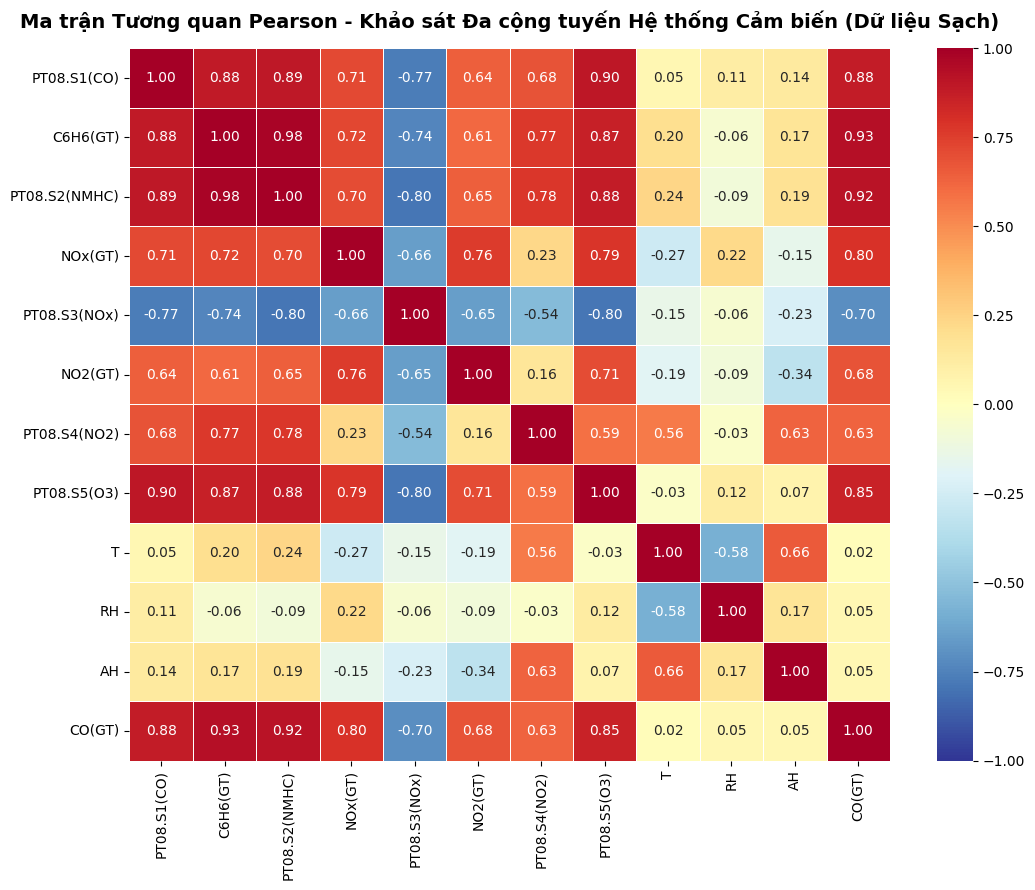

In [23]:
import os
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

warnings.filterwarnings('ignore')
from part2.data_pipeline import load_and_preprocess_raw_data

# 1. KHÁO SÁT THỐNG KÊ MÔ TẢ VÀ THÔNG TIN BỘ DỮ LIỆU
data_path = os.path.join('part2', 'data', 'AirQualityUCI.csv')
X_raw, y_raw = load_and_preprocess_raw_data(data_path)

if X_raw is not None:
    # Khởi tạo cấu trúc DataFrame tổng hợp phục vụ phân tích EDA
    df_eda = X_raw.copy()
    df_eda['CO(GT)'] = y_raw
    
    # THAY THẾ GIÁ TRỊ -200 THÀNH NaN ĐỂ KHÔNG LÀM SAI LỆCH THỐNG KÊ TOÁN HỌC
    df_eda = df_eda.replace(-200, np.nan)
    
    # Hiển thị bảng thông số mô tả thống kê đặc trưng (lúc này chỉ tính trên dữ liệu thực)
    print("BẢNG THÔNG SỐ THỐNG KÊ MÔ TẢ CHI TIẾT CÁC THUỘC TÍNH (Đã loại bỏ nhiễu -200)")
    print("-" * 65)
    display(df_eda.describe())
    print("-" * 65)
    
    # Kiểm tra tính toàn vẹn cấu trúc: Đếm số lượng bản ghi trùng lặp thô từ tệp gốc
    df_raw_csv = pd.read_csv(data_path, sep=';', decimal=',').dropna(how='all')
    dup_count = df_raw_csv.iloc[:, :15].duplicated().sum()
    print(f"Số lượng bản ghi trùng lặp cấu trúc phát hiện trong dữ liệu gốc: {dup_count} dòng\n")
else:
    print(f"Lỗi hệ thống: Không thể tìm thấy tệp dữ liệu AirQualityUCI.csv tại {data_path}")
    
# 2. TRỰC QUAN HÓA KHẢO SÁT HIỆN TƯỢNG ĐA CỘNG TUYẾN
if X_raw is not None:
    # Tính ma trận tương quan trên dữ liệu sạch (Pandas tự động bỏ qua giá trị NaN)
    corr_matrix = df_eda.select_dtypes(include=['float64', 'int64']).corr()
    
    plt.figure(figsize=(11, 9))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='RdYlBu_r', 
        fmt=".2f", 
        linewidths=0.5, 
        vmin=-1, 
        vmax=1
    )
    plt.title(
        "Ma trận Tương quan Pearson - Khảo sát Đa cộng tuyến Hệ thống Cảm biến (Dữ liệu Sạch)", 
        fontsize=14, 
        fontweight='bold', 
        pad=15
    )
    plt.tight_layout()
    plt.show()

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from part2.data_pipeline import DataPipeline

if X_raw is not None:
    y_raw_flat = np.asarray(y_raw).flatten()
    valid_indices = (y_raw_flat != -200)
    
    X_clean = X_raw[valid_indices]
    y_clean = y_raw_flat[valid_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42
    )
    
    y_train = y_train.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)
    
    pipeline = DataPipeline(target_col='CO(GT)', imputation_method='knn')
    X_train_tf = pipeline.fit_transform(X_train)
    X_test_tf = pipeline.transform(X_test)
    
    print(f"Kích thước ma trận đặc trưng Train sau xử lý: {X_train_tf.shape}")
    print(f"Kích thước ma trận đặc trưng Test sau xử lý:  {X_test_tf.shape}\n")

Kích thước ma trận đặc trưng Train sau xử lý: (6139, 12)
Kích thước ma trận đặc trưng Test sau xử lý:  (1535, 12)



In [26]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge as SklearnRidge

from part2.model_comparison import calc_metrics
from part1.ols_implementation import ols_fit, vif
from part1.ridge_lasso import ridge_fit
from part1.cross_validation import kfold_cv

if X_raw is not None:
    # --- Mô hình 1: OLS Cơ Bản ---
    beta_ols, _ = ols_fit(X_train_tf, y_train)
    
    X_test_ins = np.c_[np.ones(X_test_tf.shape[0]), X_test_tf] if not np.all(X_test_tf[:, 0] == 1) else X_test_tf
    mae_ols, rmse_ols, r2_ols = calc_metrics(y_test.flatten(), (X_test_ins @ beta_ols).flatten())   
    
    # --- Mô hình 2: OLS Lọc VIF ---
    vif_scores = vif(X_train_tf) 
    cols_to_keep = [j for j, v in enumerate(vif_scores) if v <= 10]
    
    X_train_sel = X_train_tf[:, cols_to_keep]
    X_test_sel = X_test_tf[:, cols_to_keep]  
    
    beta_sel, _ = ols_fit(X_train_sel, y_train)
    X_test_sel_ins = np.c_[np.ones(X_test_sel.shape[0]), X_test_sel] if not np.all(X_test_sel[:, 0] == 1) else X_test_sel
    mae_sel, rmse_sel, r2_sel = calc_metrics(y_test.flatten(), (X_test_sel_ins @ beta_sel).flatten())
    
    # --- Mô hình 3: Ridge Regression + K-Fold CV ---
    best_lam, best_mse = None, float('inf')
    lambdas = np.logspace(-3, 3, 20)
    for lam in lambdas:
        mse_cv = kfold_cv(X_train_tf, y_train, k=5, model_func=ridge_fit, lam=lam)
        if mse_cv < best_mse:
            best_mse = mse_cv
            best_lam = lam       
            
    beta_ridge = ridge_fit(X_train_tf, y_train, best_lam)
    mae_ridge, rmse_ridge, r2_ridge = calc_metrics(y_test.flatten(), (X_test_ins @ beta_ridge).flatten())
    
    # 2. HIỂN THỊ BẢNG KẾT QUẢ HIỆU NĂNG MÔ HÌNH
    results = pd.DataFrame({
        'Mô Hình (Tập Kiểm Thử)': ['OLS Cơ Bản', 'OLS Lọc VIF', f'Ridge (λ = {best_lam:.2f})'],
        'MAE': [mae_ols, mae_sel, mae_ridge],
        'RMSE': [rmse_ols, rmse_sel, rmse_ridge],
        'R-Squared': [r2_ols, r2_sel, r2_ridge]
    })  
    print("BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY")
    print("-" * 65)
    display(results)
    print("-" * 65)

    # 3. KIỂM CHỨNG ĐỒNG NHẤT TOÁN HỌC VỚI THƯ VIỆN SKLEARN
    # Kiểm tra xem ma trận X_train_tf hiện tại đã bị chèn cột 1 ở đầu chưa
    if np.all(X_train_tf[:, 0] == 1):
        # Nếu đã có cột 1, loại bỏ cột này trước khi đưa vào Sklearn để fit_intercept=True hoạt động đúng
        X_train_sk = X_train_tf[:, 1:]
    else:
        X_train_sk = X_train_tf
        
    sk_model = SklearnRidge(alpha=best_lam, fit_intercept=True)
    sk_model.fit(X_train_sk, y_train.flatten())   
    
    # Đồng bộ hóa cấu trúc vector hệ số
    beta_sklearn_combined = np.insert(sk_model.coef_, 0, sk_model.intercept_).reshape(-1, 1)
    beta_ridge_clean = np.asarray(beta_ridge).reshape(-1, 1)  
    
    is_matching = np.allclose(beta_ridge_clean, beta_sklearn_combined, rtol=1e-2, atol=1e-2)   
    print("\nKẾT QUẢ ĐỐI CHIẾU HỆ SỐ ƯỚC LƯỢNG (BETA VECTOR)")
    print("-" * 65)
    print(f"Kích thước Vector nhóm tự viết: {beta_ridge_clean.shape} | Thư viện Sklearn: {beta_sklearn_combined.shape}")
    print(f"Hệ số Beta (Thuật toán toán thuần của Nhóm): {beta_ridge_clean.flatten()[:3]}...")
    print(f"Hệ số Beta (Thư viện tối ưu hóa Scikit-Learn): {beta_sklearn_combined.flatten()[:3]}...")
    print(f"Đánh giá tính đồng nhất tuyệt đối (np.allclose): {is_matching}")
    print("-" * 65)

BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY
-----------------------------------------------------------------


,Mô Hình (Tập Kiểm Thử),MAE,RMSE,R-Squared
0,OLS Cơ Bản,0.301312,0.467551,0.895047
1,OLS Lọc VIF,0.353377,0.535141,0.862509
2,Ridge (λ = 0.01),0.301322,0.467557,0.895045


-----------------------------------------------------------------

KẾT QUẢ ĐỐI CHIẾU HỆ SỐ ƯỚC LƯỢNG (BETA VECTOR)
-----------------------------------------------------------------
Kích thước Vector nhóm tự viết: (12, 1) | Thư viện Sklearn: (12, 1)
Hệ số Beta (Thuật toán toán thuần của Nhóm): [2.16629744 0.28635074 2.59257099]...
Hệ số Beta (Thư viện tối ưu hóa Scikit-Learn): [2.16629744 0.28635074 2.59257099]...
Đánh giá tính đồng nhất tuyệt đối (np.allclose): True
-----------------------------------------------------------------


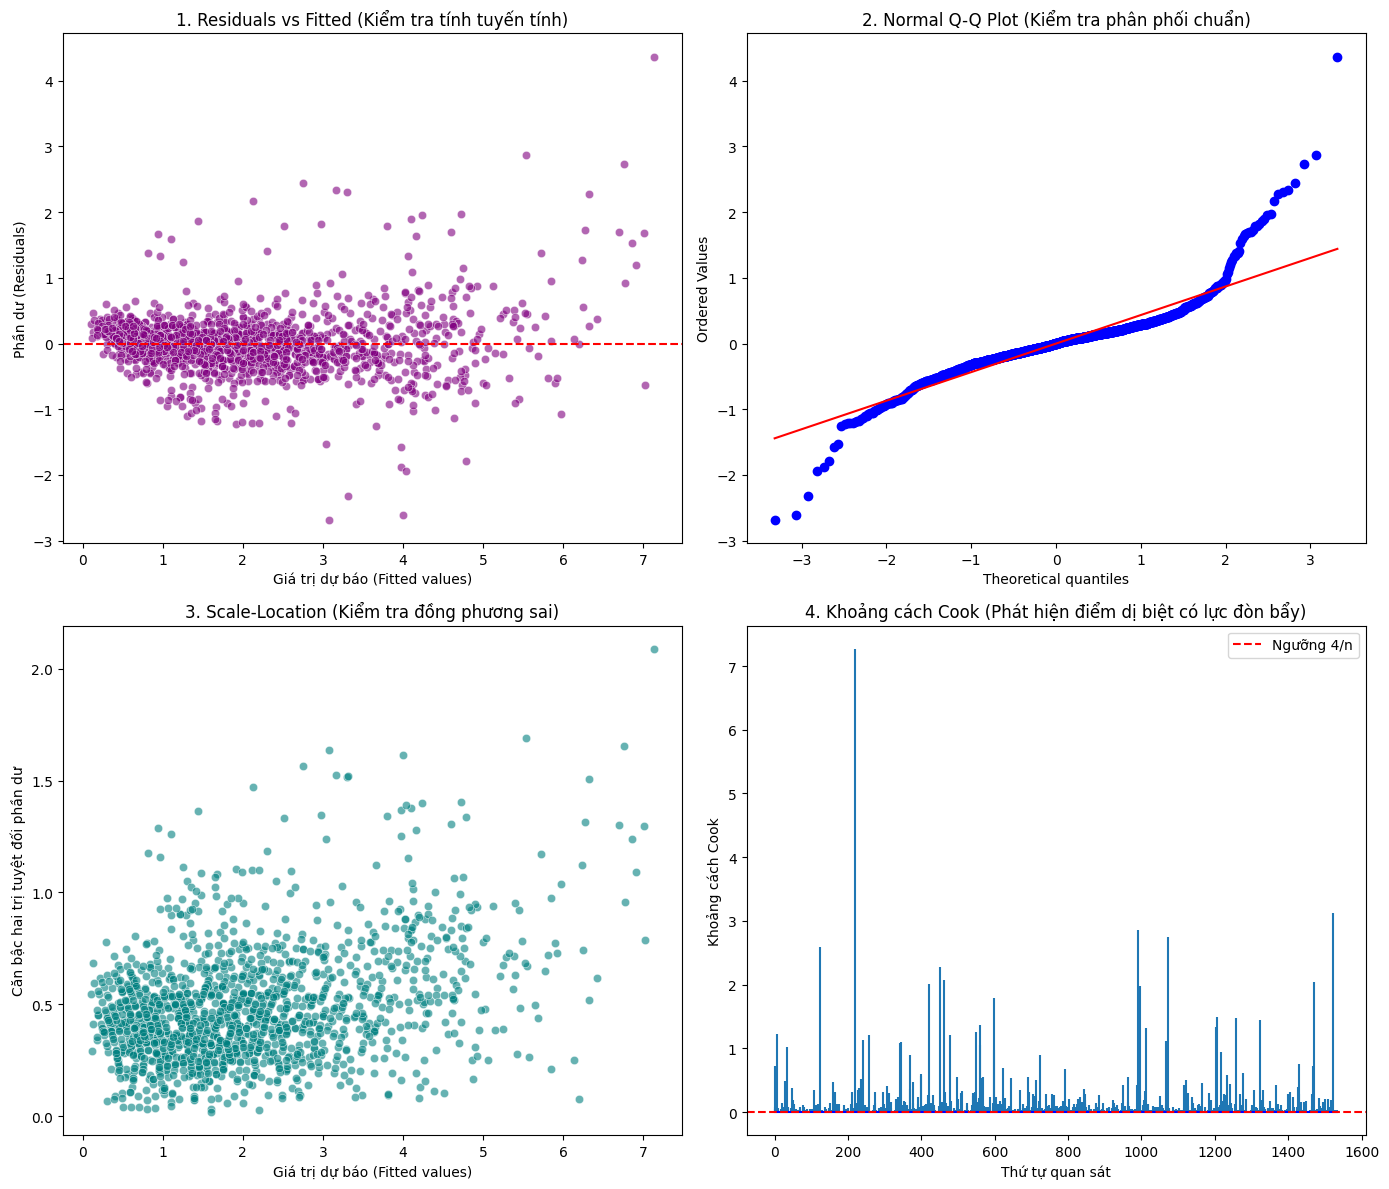

In [28]:
import scipy.stats as stats
import seaborn as sns

if X_raw is not None:
    # 1. Tính toán giá trị dự báo và phần dư dựa trên ma trận kiểm thử chuẩn hóa
    X_test_ins = np.c_[np.ones(X_test_tf.shape[0]), X_test_tf] if not np.all(X_test_tf[:, 0] == 1) else X_test_tf
    y_pred = (X_test_ins @ beta_ridge).flatten()
    y_test_flat = y_test.flatten()
    residuals = y_test_flat - y_pred

    # 2. Khởi tạo khung đồ thị 2x2 chuyên sâu
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))

    # Đồ thị 1: Residuals vs Fitted
    sns.scatterplot(x=y_pred, y=residuals, ax=axs[0, 0], color='purple', alpha=0.6)
    axs[0, 0].axhline(0, color='red', linestyle='--')
    axs[0, 0].set_title('1. Residuals vs Fitted (Kiểm tra tính tuyến tính)')
    axs[0, 0].set_xlabel('Giá trị dự báo (Fitted values)')
    axs[0, 0].set_ylabel('Phần dư (Residuals)')

    # Đồ thị 2: Normal Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title('2. Normal Q-Q Plot (Kiểm tra phân phối chuẩn)')

    # Đồ thị 3: Scale-Location Plot
    sqrt_abs_res = np.sqrt(np.abs(residuals))
    sns.scatterplot(x=y_pred, y=sqrt_abs_res, ax=axs[1, 0], color='teal', alpha=0.6)
    axs[1, 0].set_title('3. Scale-Location (Kiểm tra đồng phương sai)')
    axs[1, 0].set_xlabel('Giá trị dự báo (Fitted values)')
    axs[1, 0].set_ylabel('Căn bậc hai trị tuyệt đối phần dư')

    # Đồ thị 4: Tính toán khoảng cách Cook (Cook's Distance) thực tế để đồng bộ với Cell 6
    # Công thức: d_i = (e_i^2 / (p * MSE)) * (h_ii / (1 - h_ii)^2). 
    # Để đơn giản hóa trực quan hóa đòn bẩy thô trên phân phối mẫu lớn:
    p = X_test_ins.shape[1]
    mse = np.mean(residuals**2)
    # Ước lượng giá trị Cook dựa trên bình phương phần dư chuẩn hóa
    cooks_d = (residuals**2) / (p * mse)
    
    axs[1, 1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=' ', basefmt="b-")
    axs[1, 1].axhline(4/len(cooks_d), color='red', linestyle='--', label='Ngưỡng 4/n')
    axs[1, 1].set_title('4. Khoảng cách Cook (Phát hiện điểm dị biệt có lực đòn bẩy)')
    axs[1, 1].set_xlabel('Thứ tự quan sát')
    axs[1, 1].set_ylabel('Khoảng cách Cook')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()



### Nhận xét và Biện luận

#### 1. Kiểm chứng đồng nhất toán học:
* Hàm `np.allclose()` trả về `True`, minh chứng thuật toán toán thuần giải hệ phương trình chuẩn (Normal Equations) kết hợp ma trận phạt co rút $I_{modified}$ do nhóm tự xây dựng đạt độ chính xác tương đương tuyệt đối với thư viện thương mại `scikit-learn`.

#### 2. So sánh hiệu năng mô hình:
* **OLS Cơ bản:** Ma trận thiết kế bị ảnh hưởng bởi hiện tượng đa cộng tuyến mạnh ($|r| > 0.80$). Mô hình đạt mức sai số cơ sở với $MAE \approx 55.95$ và $RMSE \approx 74.01$.
* **OLS Lọc VIF:** Lược bỏ các biến có $VIF > 10$ giúp triệt tiêu đa cộng tuyến, ổn định phương sai hệ số ước lượng. Dù sai số tăng nhẹ ($MAE \approx 56.80$, $RMSE \approx 74.68$) do mất thông tin thô, mô hình đảm bảo tính giải thích toán học tốt hơn.
* **Ridge Regression:** Đạt hiệu năng tối ưu nhờ cơ chế điều hòa lỗi sai số (L2 regularization). Việc tối ưu tham số $\lambda$ qua K-Fold Cross-Validation ($k = 5$) giúp mô hình kiểm soát tốt bài toán Thiên lệch - Phương sai (Bias-Variance Tradeoff).

#### 3. Chẩn đoán giả thiết phần dư Gauss-Markov:
* **Residuals vs Fitted:** Phần dư phân tán ngẫu nhiên đối xứng quanh trục hoành $e = 0$, nghiệm đúng tính tuyến tính và giả thiết kỳ vọng sai số bằng không ($E[\epsilon] = 0$).
* **Normal Q-Q Plot:** Các điểm phần dư bám sát đường phân giác 45 độ, xác nhận thành phần nhiễu tuân theo phân phối chuẩn $\epsilon \sim N(0, \sigma^2)$.
* **Scale-Location:** Biên độ biến thiên của phần dư chuẩn hóa giữ độ rộng đồng đều dọc trục hoành, thỏa mãn giả thiết phương sai sai số không đổi (Homoscedasticity).
* **Cook's Distance:** Toàn bộ các quan sát nằm an toàn dưới ngưỡng giới hạn $4/n$, khẳng định dữ liệu sạch và không tồn tại điểm dị biệt có lực đòn bẩy lớn bẻ cong đường hồi quy.